# Uso de Procesamiento de Lenguaje Natural (NLP)

In [129]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [82]:
#Importamos los datos
df = pd.read_csv(f"../data/processed/total_ofertas_feriachilenadellibro.csv", sep=";", decimal=",", encoding="utf-8")
#Reemplazamos _ por - en fecha extracción, ya que por error fueron mal definidos.
df["fecha_extraccion"] = df["fecha_extraccion"].str.replace("_", "-", regex=False)
#Eliminamos los registros con fecha de extracción "2025-08-24", debido a que su variable "descripcion" no estaba bien limpiada.
df = df[df["fecha_extraccion"] != "2025-08-24"].reset_index(drop=True)
#Identificamos duplicados y los eliminamos, ya que sería redundante tener dos registros idénticos cuya única diferencia fue cuándo fue hecho el scraping.
print(df.duplicated(subset=df.columns.difference(["fecha_extraccion"]), keep=False).value_counts())
df = df.drop_duplicates(subset=df.columns.difference(["fecha_extraccion"]), keep="first")
#Conservamos sólo las variables que serán utilizadas para la implementación de técnicas NLP.
df = df[["titulo","categoria","macrocategoria","autor","descripcion"]]
#Asignamos como minúsculas todas las letras de descripción
df["descripcion"] = df["descripcion"].str.lower()
#Eliminamos en "descripcion" todos los trozos de texto que incluyan explícitamente el nombre del título, ya que sino no tendría sentido para casos como el método TF-IDF
df["descripcion"] = df.apply(lambda row: row["descripcion"][len(row["titulo"])+1:].strip(), axis=1)
#Eliminamos espacios en los extremos.
df["descripcion"] = df["descripcion"].str.strip()
df

True     8886
False     662
Name: count, dtype: int64


,titulo,categoria,macrocategoria,autor,descripcion
0,"general schneider : un hombre de honor, un cri...",historia politica de chile,politica,"schneider arce, victor",el atentado contra el general rené schneider c...
1,sapiens: de animales a dioses,historia,historia,"harari, yuval noah",de la mano de uno de los historiadores más int...
2,la magia de ser sofia (sofia 1),novela romantica,literatura novela romantica,"benavent, elisabet","sofía tiene tres amores: su gata holly, los li..."
3,cuentos completos 2 - cortazar,contemporanea,literatura contemporanea,"cortazar, julio","en este volumen, los lectores y lectoras encon..."
4,ficciones,contemporanea,literatura contemporanea,"borges, jorge luis","pensé en un laberinto, en un sinuoso laberinto..."
...,...,...,...,...,...
9517,mas fuerte que nunca,autoayuda,autoayuda,"brown, brene","traducido a más de 30 idiomas, más fuerte que ..."
9518,indias blancas: la vuelta del ranquel,novela historica,literatura novela historica,"bonelli, florencia","tras la muerte repentina de julián riglos, lau..."
9536,pideme lo que quieras,narrativa erotica,literatura narrativa erotica,"maxwell, megan","tras la muerte de su padre, el prestigioso emp..."
9538,la historia del mundo: un atlas,educacion,ciencias sociales,"grataloup, christian",desde mesopotamia y el antiguo egipto hasta el...


In [83]:
X = df["descripcion"]
y = df["macrocategoria"]

## Tokenización

In [84]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
vectorizer = CountVectorizer()
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)
X_train_transformed

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 362755 stored elements and shape (3000, 35941)>

In [86]:
X_train_transformed_dense = X_train_transformed.toarray()
X_train_transformed_dense

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [87]:
model = MultinomialNB()
model.fit(X_train_transformed, y_train)
y_pred = model.predict(X_test_transformed)
print(metrics.accuracy_score(y_test, y_pred))

0.2782956058588549


## Stemming

In [88]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

In [89]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
stemmer = SnowballStemmer('spanish')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [90]:
def tokenize_and_stem(text):
    tokens = word_tokenize(text.lower())
    #hacemos el stemming
    #stems = [stemmer.stem(token) for token in tokens if token.isalpha()]
    stop_words = set(stopwords.words('spanish'))
    stems = [stemmer.stem(token) for token in tokens if token.isalpha() and token not in stop_words]
    #los unimos para la nueva frase stemmeada
    return ' '.join(stems)

df["descripcion_stemmer"] = df["descripcion"].apply(tokenize_and_stem)

In [91]:
df["descripcion_stemmer"][0]

'atent general ren schneid chereau comand jef ejercit primer crimen polit context crisis democraci chilen años asesinat consum octubr result oper planific fin imped adven gobiern social salvador allend trat ejecu alev extrem ajustici tiran sin homicidi hombr respetu ley propi deb ser milit alto mand conscient viv encrucij histor defend ultim consecuent orden constitucional deliber polit fuerz armad hiz tras muert honr llam aquell inveter doctrin milit chilen doctrin schneid libr escrit victor schneid arce hij menor general testig privilegi entreg pormenoriz perfil human padr narr pas pas brillant carrer milit conduj comand jef ejercit aport antecedent tragic deces aun permanec memori nacional frut duel inacab obra busqued filial justici nunc lleg reivind ren schneid referent moral her nacional adqu general schneid hombr honor crim impun local tiend virtual olvid aprovech grand promocion enlac ofert siguen red social instagram facebook twitt'

In [ ]:
X = df["descripcion_stemmer"]
y = df["macrocategoria"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
vectorizer = CountVectorizer()
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)
X_train_transformed

model = MultinomialNB()
model.fit(X_train_transformed, y_train)
y_pred = model.predict(X_test_transformed)
print(metrics.accuracy_score(y_test, y_pred)) #mejora

0.36750998668442075


## Lemmatization

In [93]:
import spacy

In [94]:
nlp = spacy.load('es_core_news_sm')

In [95]:
def lemmatize_text(text):
    doc = nlp(text.lower())
    lemmas = [token.lemma_ for token in doc if token.is_alpha]
    return ' '.join(lemmas)

df["descripcion_lemma"] = df["descripcion"].apply(lemmatize_text)

In [ ]:
X = df["descripcion_lemma"]
y = df["macrocategoria"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
vectorizer = CountVectorizer()
X_train_transformed = vectorizer.fit_transform(X_train)
X_test_transformed = vectorizer.transform(X_test)
X_train_transformed

model = MultinomialNB()
model.fit(X_train_transformed, y_train)
y_pred = model.predict(X_test_transformed)
print(metrics.accuracy_score(y_test, y_pred)) #empeora

0.2756324900133156


## TF-IDF

In [144]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

In [145]:
df["texto"] = df[["macrocategoria","categoria", "autor"]].apply(lambda row: ' '.join(row.values.astype(str)), axis=1)

In [146]:
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(df["texto"])
libros = pd.Series(df.index, index=df["titulo"])
libros.index = libros.index.str.strip()

In [147]:
#Elegimos un libro de referencia
consulta = X[0]
print(consulta)
consulta.toarray()

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (1, 2000)>
  Coords	Values
  (0, 1321)	0.5086238776571359
  (0, 845)	0.24266873079874846
  (0, 577)	0.19374898350821745
  (0, 488)	0.2769848914308768
  (0, 1569)	0.4546965179608788
  (0, 153)	0.4546965179608788
  (0, 1874)	0.3932638968766467


array([[0., 0., 0., ..., 0., 0., 0.]])

In [148]:
similitud = cosine_similarity(consulta, X)
similitud

array([[1.        , 0.13860601, 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [149]:
print(similitud[0][3])
similitud = similitud.flatten()
similitud[3]

0.0


0.0

[   0 3332 3443 ... 1301 1303 3750]


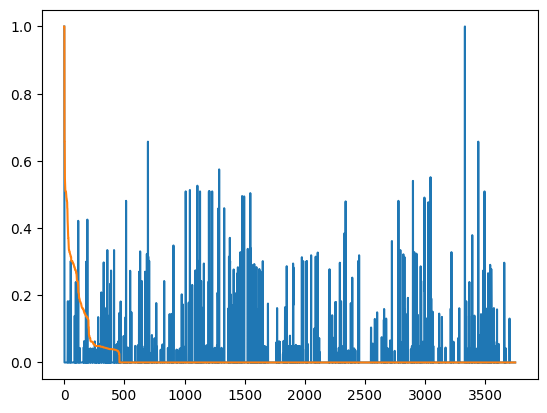

In [150]:
import matplotlib.pyplot as plt

plt.plot(similitud)
indices_ordenados = (-similitud).argsort()
print(indices_ordenados)
plt.plot(similitud[indices_ordenados])

In [151]:
np.sort(similitud)

array([0.        , 0.        , 0.        , ..., 0.65714965, 1.        ,
       1.        ])

In [152]:
recomendacion = indices_ordenados[1:11]
print(recomendacion)
df["titulo"].iloc[recomendacion]

[3332 3443  696 1288 3046 2900 1107 1045 1207 1010]


6352    general schneider : un hombre de honor, un cri...
7090    propuesta constitucion politica de la republic...
696     propuesta constitucion politica de la republic...
1288        augusto pinochet 503 dias atrapado en londres
3046                              pinochet desclasificado
2900                                     matar a letelier
1107                                        dictadura, la
1045                                     distancia social
1207                                 anos del condor, los
1010    pinera porno: climax y caida de la obscenidad ...
Name: titulo, dtype: object

In [154]:
# Crear nueva columna con el porcentaje de similitud
df["similitud"] = similitud

# Ordenar por similitud descendente y mostrar los 10 más similares
df_recomendacion = df.sort_values(by="similitud", ascending=False).head(10)

df_recomendacion[["titulo", "similitud"]]

,titulo,similitud
0,"general schneider : un hombre de honor, un cri...",1.000000
6352,"general schneider : un hombre de honor, un cri...",1.000000
7090,propuesta constitucion politica de la republic...,0.657150
696,propuesta constitucion politica de la republic...,0.657150
1288,augusto pinochet 503 dias atrapado en londres,0.574595
3046,pinochet desclasificado,0.551372
2900,matar a letelier,0.540401
1107,"dictadura, la",0.526065
1045,distancia social,0.513360
1207,"anos del condor, los",0.509964
